# Lab 1 — Digital Image Fundamentals
### Images as matrices · Sampling · Quantization

**Reference:** Gonzalez & Woods, *Digital Image Processing*, 4th ed. — Chapter 1 (Introduction) and Chapter 2 (Digital Image Fundamentals: image sampling and quantization).

**Tools:** Python 3, NumPy, OpenCV, Matplotlib.

**By the end of this lab you will be able to:**
1. Read, display, and save images with OpenCV and Matplotlib.
2. Explain that a digital image is just a NumPy array and inspect its size, type, and range.
3. Access single pixels, regions (ROI), rows, and columns using indexing and slicing.
4. Create synthetic images from scratch.
5. Demonstrate the effect of reducing **spatial resolution** (sampling) and **intensity resolution** (quantization).
6. Compute the storage required for an image.

## 0. Setup
Install once (from a terminal): `pip install opencv-python numpy matplotlib scikit-image`

The cell below imports the libraries and **creates two sample images** in the current folder (a grayscale "cameraman" and a colour "astronaut") so that you can practise `cv2.imwrite` / `cv2.imread` right away. It also defines a small helper, `show()`, that we will use throughout.

In [1]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage import data          # only used here to create the sample files

# --- create sample images on disk (once) ---
if not os.path.exists("cameraman.png"):
    cv2.imwrite("cameraman.png", data.camera())                                   # 8-bit grayscale
if not os.path.exists("astronaut.png"):
    cv2.imwrite("astronaut.png", cv2.cvtColor(data.astronaut(), cv2.COLOR_RGB2BGR))  # 8-bit colour

def show(images, titles=None, cols=None, figsize=None):
    """Display one or more uint8 images (gray or RGB) side by side, with a FIXED 0-255 gray scale."""
    n = len(images)
    cols = cols or n
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=figsize or (4 * cols, 4 * rows))
    axes = np.atleast_1d(axes).ravel()
    titles = titles or [""] * n
    for ax, im, t in zip(axes, images, titles):
        if im.ndim == 2:
            ax.imshow(im, cmap="gray", vmin=0, vmax=255, interpolation="nearest")
        else:
            ax.imshow(im, interpolation="nearest")
        ax.set_title(t, fontsize=10)
        ax.axis("off")
    for ax in axes[n:]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

print("Ready ✔")

Ready ✔


## 1. Theory recap — what *is* a digital image?

An image is a two-variable function $f(x, y)$ whose value at $(x,y)$ is the **intensity** (brightness) at that point. In a **digital** image, $x$, $y$, and the intensity are all **discrete** and finite, so the image is simply an $M \times N$ matrix:

$$
f(x,y)=\begin{bmatrix}
f(0,0) & f(0,1) & \cdots & f(0,N-1)\\
f(1,0) & f(1,1) & \cdots & f(1,N-1)\\
\vdots & \vdots & \ddots & \vdots\\
f(M-1,0) & f(M-1,1) & \cdots & f(M-1,N-1)
\end{bmatrix}
$$

Each element is a **pixel**.

**Coordinate convention.** The origin is at the **top-left** corner. $x$ runs **down** the rows and $y$ runs **across** the columns. In NumPy this is exactly `img[x, y]` = `img[row, col]`.

> ⚠️ OpenCV drawing functions and points use the opposite order, $(x, y) = (\text{col}, \text{row})$. Keep this in mind.

**Intensity levels.** With $k$ bits per pixel there are $L = 2^k$ possible gray levels, in the range $[0,\,L-1]$. For an 8-bit image: $L = 256$ and the range is $[0, 255]$ (0 = black, 255 = white).

**Storage.** The number of bits needed to store an $M \times N$ image with $k$ bits per pixel is

$$b = M \times N \times k$$

**Two kinds of resolution**
- **Spatial resolution** — how many pixels ($M \times N$). Reduced by *sampling* fewer points.
- **Intensity resolution** — how many gray levels ($L$). Reduced by *quantizing* to fewer levels.

## 2. Reading, displaying, and saving images
`cv2.imread(path, flag)` returns a NumPy array:
- `cv2.IMREAD_GRAYSCALE` (or `0`) → 2-D array, shape `(M, N)`
- `cv2.IMREAD_COLOR` (default) → 3-D array, shape `(M, N, 3)` in **B, G, R** order

gray shape: (512, 512)
bgr  shape: (512, 512, 3)


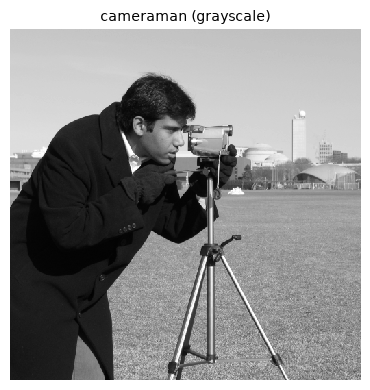

In [2]:
gray = cv2.imread("cameraman.png", cv2.IMREAD_GRAYSCALE)
bgr  = cv2.imread("astronaut.png")          # default = colour, BGR order

# imread does NOT raise an error for a wrong path: it silently returns None
assert gray is not None and bgr is not None, "Could not read the image files!"

print("gray shape:", gray.shape)
print("bgr  shape:", bgr.shape)
show([gray], ["cameraman (grayscale)"], figsize=(4, 4))

### The BGR vs RGB trap
Matplotlib expects **RGB**, OpenCV gives **BGR**. If you forget to convert, red and blue swap.

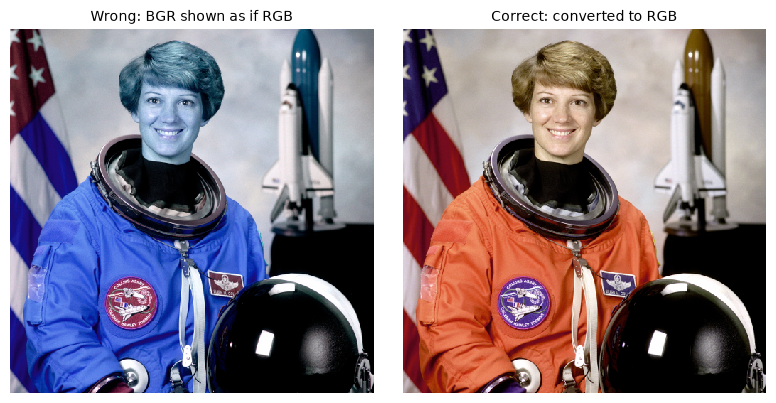

In [3]:
rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
show([bgr, rgb], ["Wrong: BGR shown as if RGB", "Correct: converted to RGB"], figsize=(8, 4))

### Always fix the display range
By default `plt.imshow` **stretches** the displayed range to the min/max of the data, which can hide real differences in brightness. Compare:

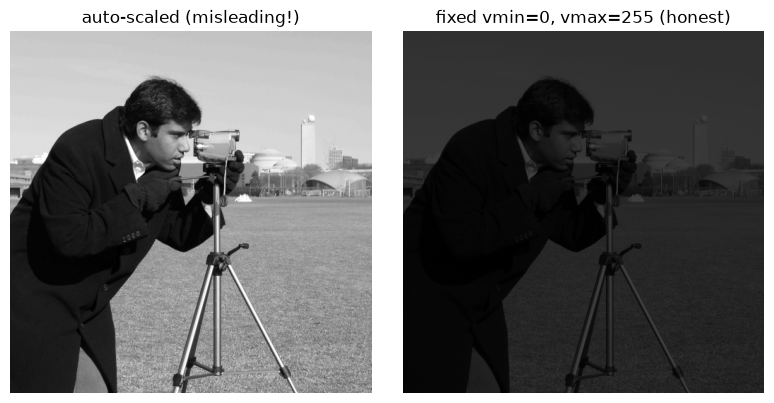

dark image range: 0 to 63


In [4]:
dark = gray // 4          # a very dark version of the image (values 0..63)

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(dark, cmap="gray");                    ax[0].set_title("auto-scaled (misleading!)")
ax[1].imshow(dark, cmap="gray", vmin=0, vmax=255);  ax[1].set_title("fixed vmin=0, vmax=255 (honest)")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()
print("dark image range:", dark.min(), "to", dark.max())

### Saving an image

In [6]:
cv2.imwrite("Lab1cameraman_copy.png", gray)
print("Saved. File exists:", os.path.exists("cameraman_copy.png"))

Saved. File exists: False


## 3. Image properties
Since an image is a NumPy array, all its properties come from the array attributes.

In [7]:
M, N = gray.shape
k = gray.dtype.itemsize * 8            # bits per pixel

print(f"Size (M x N)        : {M} x {N}")
print(f"Number of pixels    : {gray.size}")
print(f"Data type           : {gray.dtype}")
print(f"Bits per pixel (k)  : {k}   ->  L = 2^k = {2**k} gray levels")
print(f"Min / Max intensity : {gray.min()} / {gray.max()}")
print(f"Mean intensity      : {gray.mean():.2f}")
print(f"Storage b = M*N*k   : {M*N*k:,} bits = {M*N*k/8/1024:.0f} KB")
print(f"Colour image shape  : {bgr.shape}  ->  {bgr.shape[2]} channels, {bgr.shape[2]*8} bits per pixel")
print(f"PNG file on disk    : {os.path.getsize('cameraman.png')/1024:.0f} KB   (smaller than raw: the file is compressed - see Chapter 8)")

Size (M x N)        : 512 x 512
Number of pixels    : 262144
Data type           : uint8
Bits per pixel (k)  : 8   ->  L = 2^k = 256 gray levels
Min / Max intensity : 0 / 255
Mean intensity      : 129.06
Storage b = M*N*k   : 2,097,152 bits = 256 KB
Colour image shape  : (512, 512, 3)  ->  3 channels, 24 bits per pixel
PNG file on disk    : 145 KB   (smaller than raw: the file is compressed - see Chapter 8)


## 4. Accessing pixels, regions, rows and columns
Remember: `img[row, col]`, indexing starts from **0**, and slices `a:b` include `a` but exclude `b`.

Pixel at row 100, col 150 : 211
Top-left 5x5 block:
 [[200 200 200 200 199]
 [200 199 199 200 199]
 [199 199 199 200 200]
 [200 200 199 199 199]
 [200 200 200 200 199]]
ROI shape: (200, 200)


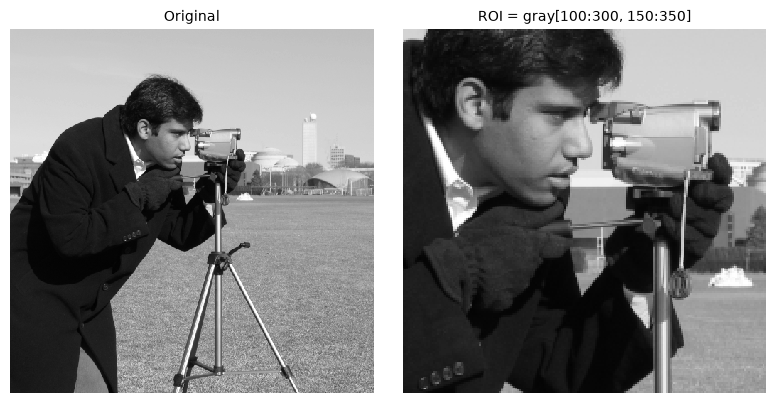

In [8]:
print("Pixel at row 100, col 150 :", gray[100, 150])
print("Top-left 5x5 block:\n", gray[:5, :5])

roi = gray[100:300, 150:350]                 # Region Of Interest: rows 100..299, cols 150..349
print("ROI shape:", roi.shape)
show([gray, roi], ["Original", "ROI = gray[100:300, 150:350]"], figsize=(8, 4))

### Modifying pixels (work on a copy!)

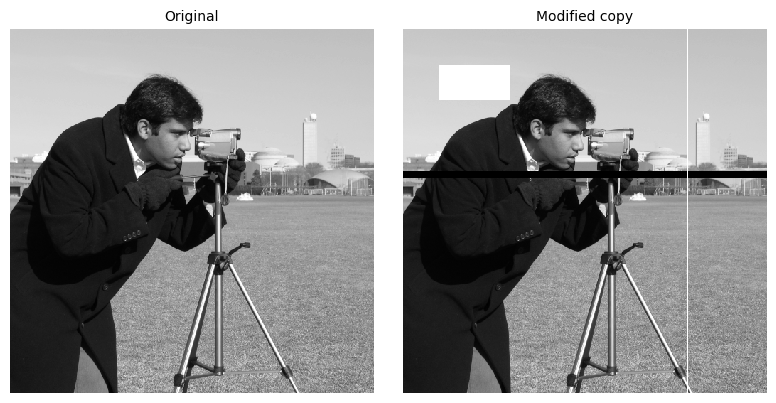

In [ ]:
img2 = gray.copy()                 # .copy() gives an independent array
img2[50:100, 50:150] = 255         # white rectangle
img2[200:210, :]     = 0           # black horizontal band across the whole width
img2[:, 400]         = 255         # one white vertical line
show([gray, img2], ["Original", "Modified copy"], figsize=(8, 4))

> ⚠️ **Slices are *views*, not copies.** Changing a slice changes the array it came from. Run the next cell and read the output carefully.

In [9]:
tmp = gray.copy()
view = tmp[:10, :10]        # a VIEW of tmp
view[:] = 0                 # we only "touched" the view...
print("Top-left 3x3 of tmp after modifying the view:\n", tmp[:3, :3])   # ...but tmp changed too!

Top-left 3x3 of tmp after modifying the view:
 [[0 0 0]
 [0 0 0]
 [0 0 0]]


### Intensity profile along a row

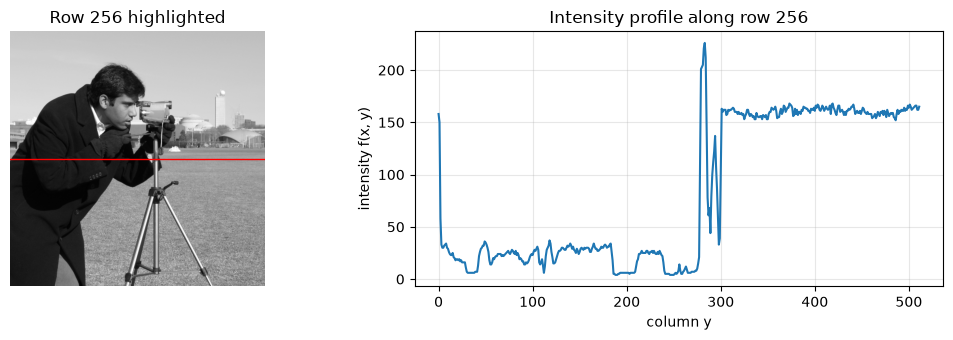

In [10]:
row = 256
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].imshow(gray, cmap="gray", vmin=0, vmax=255)
ax[0].axhline(row, color="red", lw=1)
ax[0].set_title(f"Row {row} highlighted"); ax[0].axis("off")
ax[1].plot(gray[row, :])
ax[1].set_xlabel("column y"); ax[1].set_ylabel("intensity f(x, y)")
ax[1].set_title(f"Intensity profile along row {row}"); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 5. Creating images from scratch
Because an image is just an array, we can build one with NumPy.

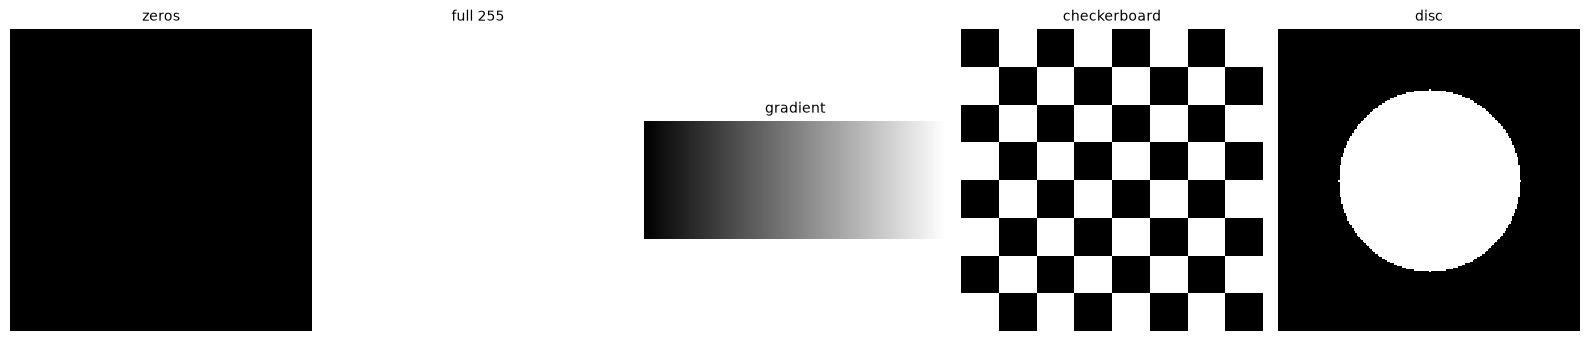

In [27]:
black    = np.zeros((100, 100), dtype=np.uint8)
white    = np.full((100, 100), 255, dtype=np.uint8)
gradient = np.tile(np.linspace(0, 255, 256).astype(np.uint8), (100, 1))       # left-to-right ramp

# checkerboard: integer-divide the coordinates by the square size, then look at the parity
idx = np.indices((200, 200)) // 25
checker = (((idx[0] + idx[1]) % 2) * 255).astype(np.uint8)

# white disc: boolean mask from the circle equation (x-cx)^2 + (y-cy)^2 <= r^2
x, y = np.ogrid[:200, :200]
disc = np.zeros((200, 200), dtype=np.uint8)
disc[(x - 100) ** 2 + (y - 100) ** 2 <= 60 ** 2] = 255

show([black, white, gradient, checker, disc],
     ["zeros", "full 255", "gradient", "checkerboard", "disc"], figsize=(16, 3.5))

### The `uint8` overflow trap
`uint8` can only hold 0–255. Arithmetic on NumPy `uint8` arrays **wraps around** (modulo 256) instead of clipping.

In [28]:
a = np.array([[200, 250]], dtype=np.uint8)      # 2-D on purpose: cv2 functions expect image-shaped arrays
b = np.array([[100, 100]], dtype=np.uint8)
print("numpy  a + b        :", (a + b).ravel(), "   <- wrapped around (200+100 = 300 -> 300-256 = 44)")
print("cv2.add(a, b)       :", cv2.add(a, b).ravel(), "   <- saturated at 255")
print("float then clip     :", np.clip(a.astype(np.int16) + b, 0, 255).astype(np.uint8))

numpy  a + b        : [44 94]    <- wrapped around (200+100 = 300 -> 300-256 = 44)
cv2.add(a, b)       : [255 255]    <- saturated at 255
float then clip     : [[255 255]]


## 6. Sampling — reducing spatial resolution
Keeping every $f$-th pixel in both directions gives an image with $M/f \times N/f$ pixels. That is **subsampling**.

In NumPy: `img[::f, ::f]`.

To *compare* images of different sizes fairly, we show each one at the same physical size by **replicating** every pixel $f \times f$ times (`np.repeat`). This is nearest-neighbour enlargement; interpolation methods are the topic of the next lab.

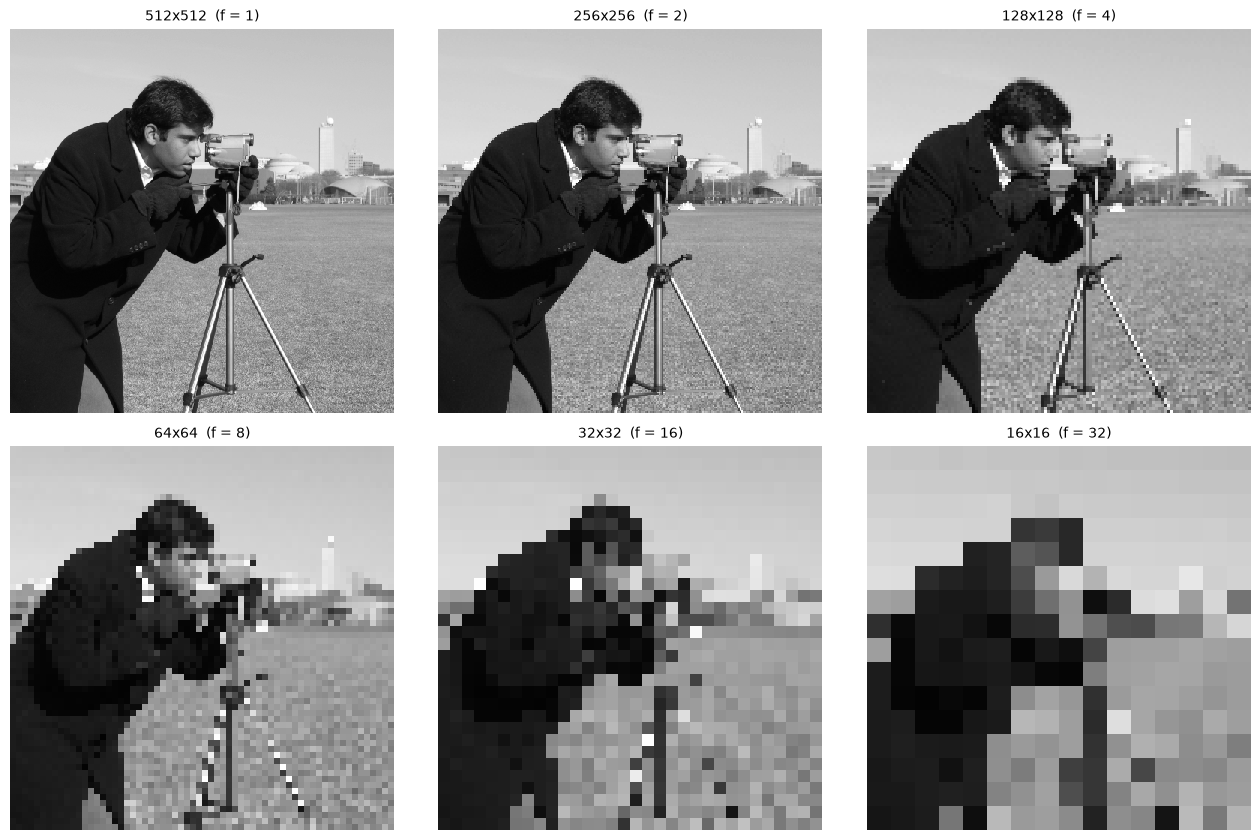

f =  1: 512 x 512 pixels -> 262,144 pixels (100.00 % of the original)
f =  2: 256 x 256 pixels ->  65,536 pixels ( 25.00 % of the original)
f =  4: 128 x 128 pixels ->  16,384 pixels (  6.25 % of the original)
f =  8:  64 x 64  pixels ->   4,096 pixels (  1.56 % of the original)
f = 16:  32 x 32  pixels ->   1,024 pixels (  0.39 % of the original)
f = 32:  16 x 16  pixels ->     256 pixels (  0.10 % of the original)


In [29]:
factors = [1, 2, 4, 8, 16, 32]
small, big, titles = [], [], []
for f in factors:
    s = gray[::f, ::f]                                    # subsample
    b = np.repeat(np.repeat(s, f, axis=0), f, axis=1)     # replicate back to 512x512 for display
    small.append(s); big.append(b)
    titles.append(f"{s.shape[1]}x{s.shape[0]}  (f = {f})")

show(big, titles, cols=3, figsize=(13, 8.5))
for f, s in zip(factors, small):
    print(f"f = {f:>2}: {s.shape[0]:>3} x {s.shape[1]:<3} pixels -> {s.size:>7,} pixels ({s.size/gray.size*100:6.2f} % of the original)")

**Observe:** as the number of samples drops, fine details disappear first, then edges become jagged, and finally the *checkerboard effect* (visible square blocks) dominates.

## 7. Quantization — reducing intensity resolution
We keep the same number of pixels but allow only $L = 2^k$ distinct gray levels, with $k = 8, 7, \dots, 1$.

Procedure used here (with rounding, and rescaled back to 0–255 so that all images are displayed on the same scale):

$$
q = \operatorname{round}\!\left(\frac{f}{255}\,(L-1)\right)\in\{0,\dots,L-1\},
\qquad
g = q\cdot\frac{255}{L-1}
$$

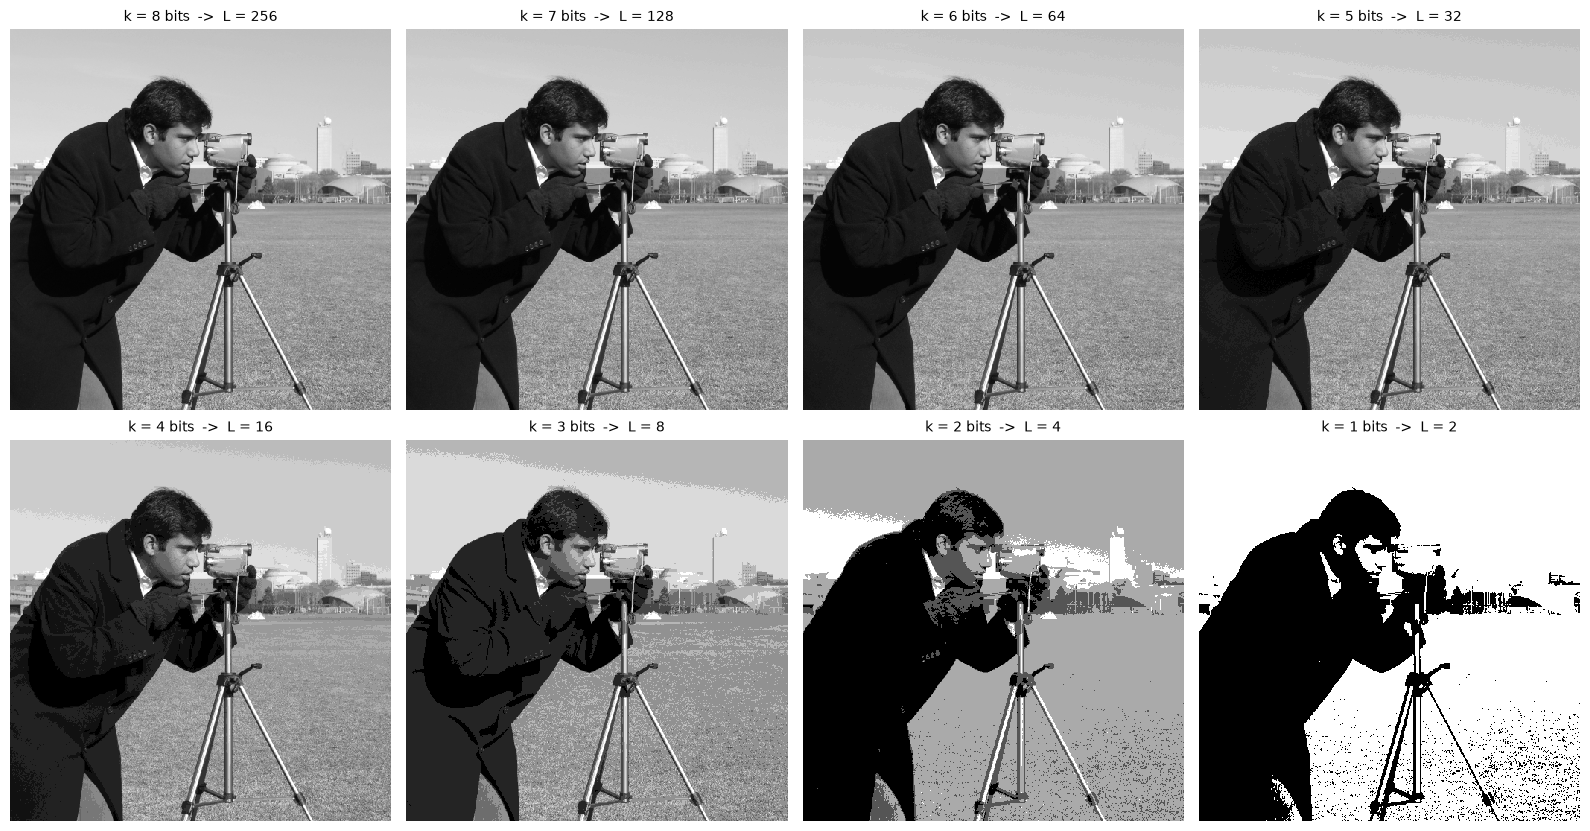

Distinct gray levels actually present in each image:
  k = 8: 256  (max possible 256)
  k = 7: 128  (max possible 128)
  k = 6:  64  (max possible 64)
  k = 5:  32  (max possible 32)
  k = 4:  16  (max possible 16)
  k = 3:   8  (max possible 8)
  k = 2:   4  (max possible 4)
  k = 1:   2  (max possible 2)


In [30]:
def levels_reduced(img, k):
    L = 2 ** k
    q = np.round(img.astype(np.float64) / 255 * (L - 1))      # integer level in 0..L-1
    return (q * 255 / (L - 1)).astype(np.uint8)                # back to 0..255 for display

ks = [8, 7, 6, 5, 4, 3, 2, 1]
quantized = [levels_reduced(gray, k) for k in ks]
titles = [f"k = {k} bits  ->  L = {2**k}" for k in ks]
show(quantized, titles, cols=4, figsize=(16, 8.5))

print("Distinct gray levels actually present in each image:")
for k, q in zip(ks, quantized):
    print(f"  k = {k}: {len(np.unique(q)):>3}  (max possible {2**k})")

**Observe:** around $k = 5$ or $4$ and below, smooth regions (look at the **sky**) break into visible bands. This artefact is called **false contouring**. Notice that the spatial detail (edges) is still fine — quantization affects *smooth areas* most.

## 8. What does it cost? Storage vs resolution
Both kinds of resolution reduction save storage: $b = M \times N \times k$.

In [31]:
def storage_kb(M, N, k):
    return M * N * k / 8 / 1024

print(f"{'M x N':>10} | " + " | ".join(f"k={k}" .rjust(9) for k in [8, 4, 2, 1]))
print("-" * 58)
for f in [1, 2, 4, 8]:
    m, n = M // f, N // f
    print(f"{f'{m}x{n}':>10} | " + " | ".join(f"{storage_kb(m, n, k):7.1f}KB" for k in [8, 4, 2, 1]))

     M x N |       k=8 |       k=4 |       k=2 |       k=1
----------------------------------------------------------
   512x512 |   256.0KB |   128.0KB |    64.0KB |    32.0KB
   256x256 |    64.0KB |    32.0KB |    16.0KB |     8.0KB
   128x128 |    16.0KB |     8.0KB |     4.0KB |     2.0KB
     64x64 |     4.0KB |     2.0KB |     1.0KB |     0.5KB


### Key takeaways
- A digital image is an array; `img[row, col]` is the pixel at $(x, y)$ with the origin at the top-left.
- **Sampling** controls spatial resolution → too few samples give blocky images (checkerboard effect).
- **Quantization** controls the number of gray levels → too few levels give **false contours**.
- `uint8` arithmetic wraps around; use `cv2.add` or convert to a wider type and clip.
- Always display gray images with a fixed range (`vmin=0, vmax=255`) when comparing them.

---
# Exercises
Write your solutions in the code cells that follow each question. Use the images and helper `show()` from above.

### Exercise 1 — Storage calculation
A medical scanner produces images of $1024 \times 1024$ pixels with **12 bits** per pixel.
1. How many gray levels does each pixel have?
2. How many **megabytes** are needed to store one image (1 MB = $1024^2$ bytes)?
3. Create an array of zeros of that size with dtype `np.uint16` (the smallest NumPy type that can hold 12-bit values) and print its `.nbytes`. Why is the result different from your answer in (2)?

In [35]:
# 1. How many gray levels does each pixel have?
print(f"Gray levels: {2 ** 12}")

# 2. How many megabytes are needed to store one image (1 MB = 1024^2 bytes)?
print(f"Megabytes = {1024 * 1024 * 12}")

# 3. Create an array of zeros of that size with dtype `np.uint16` (the smallest NumPy type that can hold 12-bit values) and print its `.nbytes`. Why is the result different from your answer in (2)?
medical_img = np.zeros((1024, 1024), dtype = np.uint16)
print(f"Number of bytes = {medical_img.nbytes}")
print("The difference happens due to the unit16 data type which uses 16 bits per pixel\n"
      "while the desired output used 12 bits per pixel\n"
      f"No. of bytes with 12 bits = {(1024 * 1024 * 12)/8}\n"
      f"No. of bytes with 16 bits = {medical_img.nbytes}")

Gray levels: 4096
Megabytes = 12582912
Number of bytes = 2097152
The difference happens due to the unit16 data type which uses 16 bits per pixel
while the desired output used 12 bits per pixel
No. of bytes with 12 bits = 1572864.0
No. of bytes with 16 bits = 2097152


### Exercise 2 — Slicing only
Using **only slicing** (no loops, no OpenCV functions) on `gray`, produce and display:
1. The central quarter of the image (the middle 256 × 256 block).
2. The image flipped horizontally (mirror left-right).
3. The image flipped vertically (upside-down).
4. The image transposed (rows ↔ columns).

*Hint: a slice with step `-1` reverses an axis.*

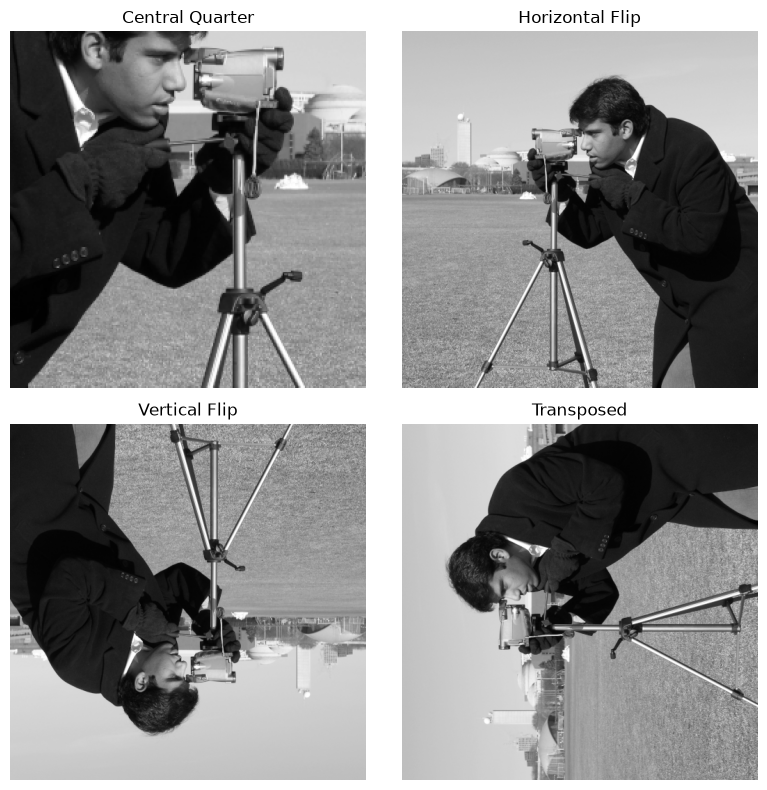

In [36]:
import matplotlib.pyplot as plt

# 1
h, w = gray.shape
start_h, end_h = h // 4, 3 * (h // 4)
start_w, end_w = w // 4, 3 * (w // 4)
central_quarter = gray[start_h:end_h, start_w:end_w]

# 2
flipped_horizontal = gray[:, ::-1]

# 3
flipped_vertical = gray[::-1, :]

# 4
transposed = gray.T

# Display all results using matplotlib
fig, axes = plt.subplots(2, 2, figsize=(8, 8))

axes[0, 0].imshow(central_quarter, cmap="gray")
axes[0, 0].set_title("Central Quarter")

axes[0, 1].imshow(flipped_horizontal, cmap="gray")
axes[0, 1].set_title("Horizontal Flip")

axes[1, 0].imshow(flipped_vertical, cmap="gray")
axes[1, 0].set_title("Vertical Flip")

axes[1, 1].imshow(transposed, cmap="gray")
axes[1, 1].set_title("Transposed")

for ax in axes.ravel():
  ax.axis("off")

plt.tight_layout()
plt.show()

### Exercise 3 — Synthetic image
Build a $256 \times 256$ `uint8` image made of:
- a checkerboard with squares of $32 \times 32$ pixels (black and white), and
- a **gray disc** (intensity 128) of radius 64 centred in the image, drawn on top of the checkerboard.

Display it and print the set of distinct intensity values it contains.

In [68]:
import pandas as pd

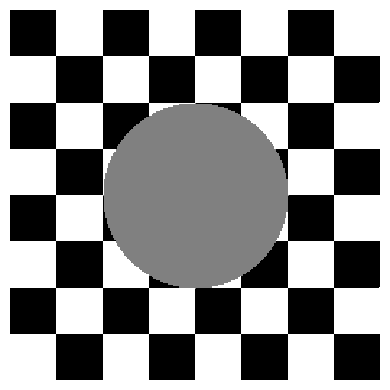

Set of Distinct intensity values: [  0 128 255]


In [72]:
idx = np.indices((256, 256)) // 32
checker = (((idx[0] + idx[1]) % 2) * 255).astype(np.uint8)

x, y = np.ogrid[:256, :256]
checker[(x - 128)**2 + (y - 128)**2 <= 64**2] = 128
show([checker])
print(f"Set of Distinct intensity values: {np.unique(checker)}")

### Exercise 4 — Resolution on a colour image
Write a function `reduce_resolution(img, f)` that subsamples an image by a factor `f` and then replicates it back to its original size (the same steps as Part 6). Make sure it works for **both** grayscale and colour images. Apply it to the RGB astronaut image with $f = 1, 4, 8, 16$.

*Question:* at which factor does the face stop being recognisable? Why do details like the text on the mission patch and the name tag vanish first?

Question answered:\
8\
because they are small relative to the overall image

In [100]:
def reduce_resolution(img, f):
    small, big, titles = [], [], []
    s = img[::f, ::f]                                    # subsample
    b = np.repeat(np.repeat(s, f, axis=0), f, axis=1)     # replicate back to 512x512 for display
    small.append(s); big.append(b)
    titles.append(f"{s.shape[1]}x{s.shape[0]}  (f = {f})")
    show(big, titles)

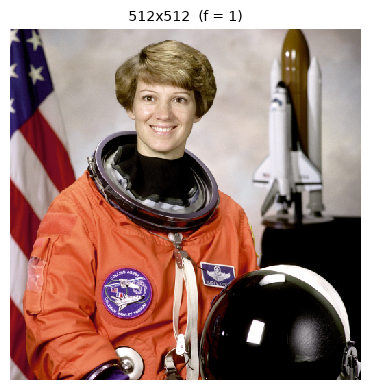

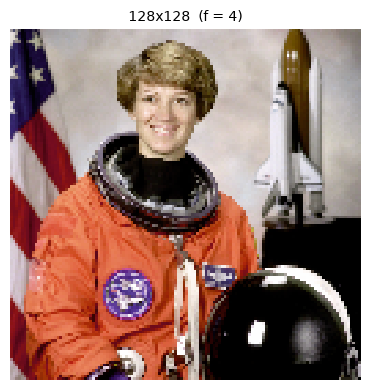

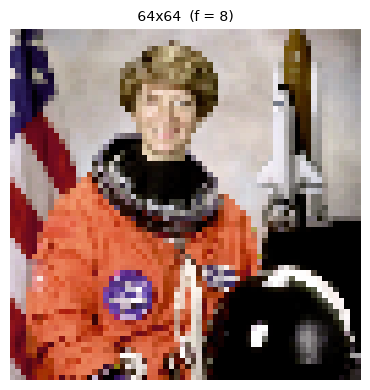

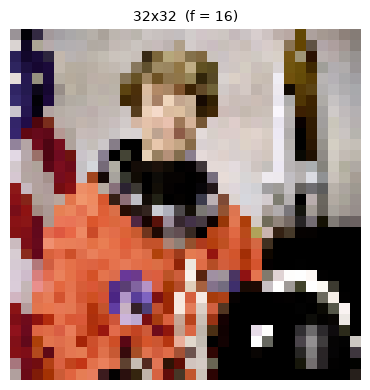

In [101]:
astro = plt.imread("astronaut.png")
factors = [1, 4, 8, 16]
photos = []
for factor in factors:
    reduce_resolution(astro, factor)



### Exercise 5 — Quantization by bit-shifting
A common shortcut for reducing gray levels is to **drop the least-significant bits** using a right shift: `img >> (8 - k)`.
1. Implement `levels_shift(img, k)` this way and apply it with $k = 3$.
2. Print the maximum value of the result and compare it with `levels_reduced(gray, 3)` from Part 7. Why does the shifted image look darker?
3. Fix it: rescale the shifted result so that its maximum becomes 255, and show the three images side by side.

levels_shift max: 7
levels_reduced max: 255
the shifted image looks darker because the maximum value is 7, it was only normalized without backscaling it


C:\Users\OC\AppData\Local\Temp\ipykernel_22932\1007289596.py:12: RuntimeWarning: invalid value encountered in divide
  return (q * 255 / (L - 1)).astype(np.uint8)
C:\Users\OC\AppData\Local\Temp\ipykernel_22932\1007289596.py:12: RuntimeWarning: invalid value encountered in cast
  return (q * 255 / (L - 1)).astype(np.uint8)


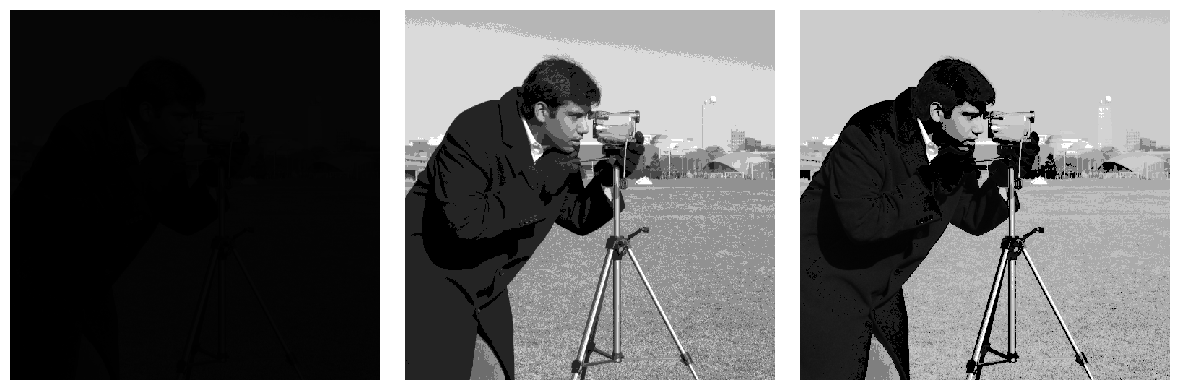

In [107]:
def levels_reduced(img, k):
    L = 2 ** k
    q = np.round(img.astype(np.float64) / 255 * (L - 1))      # integer level in 0..L-1
    return (q * 255 / (L - 1)).astype(np.uint8)                # back to 0..255 for display

def levels_shift(img, k):
    return img >> 8 - k

def levels_shift_fix(img, k):
    L = img >> 8 - k
    q = np.round(img.astype(np.float64) / 255 * (L - 1))      # integer level in 0..L-1
    return (q * 255 / (L - 1)).astype(np.uint8)

print(f"levels_shift max: {levels_shift(gray, 3).max()}\nlevels_reduced max: {levels_reduced(gray, 3).max()}")
print(f'the shifted image looks darker because the maximum value is 7, it was only normalized without backscaling it')
show([levels_shift(gray, 3), levels_reduced(gray, 3), levels_shift_fix(gray, 3)])


### Exercise 6 — Brightening, the wrong way and the right way
Add 100 to every pixel of `gray` in three ways and display the results:
1. Plain NumPy: `gray + 100`
2. `cv2.add(gray, 100 * np.ones_like(gray))`
3. Convert to `int16`, add, clip to `[0, 255]`, convert back to `uint8`

Explain why the first result contains dark "holes" in the bright regions, and whether 2 and 3 are identical.

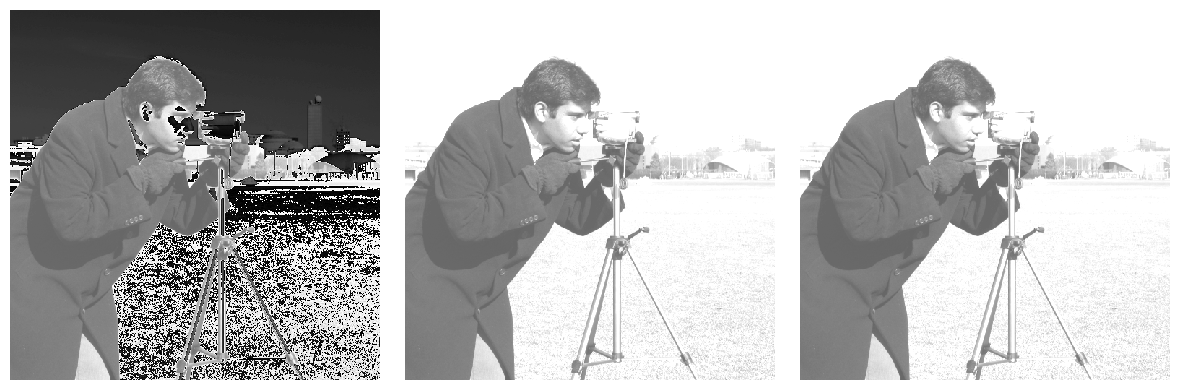

because the gray image uses uint8, it wrapps back using the modulas, so if a pixel had high value it is converted to a small number(dark) using the moduls, and ye 2 and 3 are identical


In [110]:
numpy_gray = gray + 100
cv_gray = cv2.add(gray, 100 * np.ones_like(gray))

convert_gray = gray.astype(np.int16) + 100
convert_gray = np.clip(convert_gray, 0, 255).astype(np.uint8)

show([numpy_gray, cv_gray, convert_gray])
print("because the gray image uses uint8, it wrapps back using the modulas, so if a pixel had high value it is converted to a small number(dark) using the moduls, and ye 2 and 3 are identical")

---
# Take-home assignment
**Measuring the damage.** The images in Part 7 *look* worse as $k$ decreases — now measure it.

1. For $k = 1, \dots, 7$, quantize `gray` and compute the **Mean Squared Error** and **PSNR** between the original and the quantized image:
$$
\text{MSE}=\frac{1}{MN}\sum_{x,y}\bigl[f(x,y)-g(x,y)\bigr]^2,\qquad
\text{PSNR}=10\log_{10}\frac{255^2}{\text{MSE}}\ \text{dB}
$$
2. Plot PSNR versus $k$.
3. In a markdown cell, answer: *From which $k$ does the improvement in PSNR seem to flatten? Does the PSNR curve agree with what you see with your eyes?*

*(PSNR will be used again in the compression chapter.)*

k = 5\
no

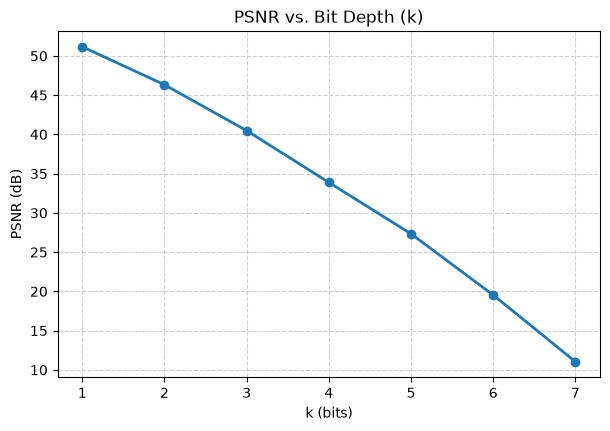

In [119]:
ks = [7, 6, 5, 4, 3, 2, 1]
quantized = [levels_reduced(gray, k) for k in ks]
titles = [f"k = {k} bits  ->  L = {2**k}" for k in ks]
mse = [np.mean((quantized_img.astype(np.float64) - gray.astype(np.float64)) ** 2) for quantized_img in quantized]
psnr = [10 * np.log10((255 ** 2) / m) for m in mse]
ks.sort()
plt.figure(figsize=(7, 4.5))
plt.plot(ks, psnr, marker='o', linewidth=2, color='tab:blue')
plt.xlabel("k (bits)")
plt.ylabel("PSNR (dB)")
plt.title("PSNR vs. Bit Depth (k)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()


*Your answer:*